<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/images/ATLASOD.gif?raw=1" style="width:50%"></CENTER>

# Kinematics

How do numbers in a database represent millions of particles that exist for fractions of a second? In this notebook, we'll look at the basics of kinematics in particle physics to demonstrate the inner workings of high energy physics research. We will go over:

- Four-vectors
- Energy and Momentum Conservation
- Invariant Mass
- Reference Frames and Lorentz Boosts
- Two-Body Decays
- Detector Data and Monte Carlo Simulation

These concepts will be accompanied by a sample analysis to exemplify how they are used, and how they can be recreated in your analyses!

### First time setup on your computer (Skip on MyBinder)
This first cell only needs to be run the first time you open this notebook on your computer.

If you close Jupyter and re-open it on the same computer, you won't need to run this first cell again.

If you open the notebook on MyBinder, you don't need to run this cell.

In [ ]:
#install required packages
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

### To Setup Everytime
We're going to be using a number of tools to help us:
* uproot: lets us read [.root](https://root.cern/) files typically used in particle physics into data formats used in Python
* pandas: lets us store data as dataframes or arrays, formats widely used in Python
* numpy: provides numerical calculations such as histogramming
* matplotlib: common tool for making plots, figures, images, visualisations
* awkward: a python package for dealing conveniently with lists that are different lengths
* vector: a python package for making and manipulating vectors

In case you see an error when importing one of these packages, try restarting the kernel (the "session" in Colab) to make sure the packages that were installed in the last cell have been properly loaded.

In [2]:
import pandas as pd # to store data as dataframes
import numpy as np # for numerical calculations such as histogramming
import uproot # to read .root files as dataframes
import matplotlib.pyplot as plt # for plotting
import awkward as ak # for handling complex and nested data structures efficiently
import vector # For convenient 4-vector manipulation
import atlasopenmagic as atom # For ATLAS-specific analysis tools and data
vector.register_awkward()

## Our Analysis

To attach the kinematic information we will learn in this notebook to common analytical techniques, we will be looking at a specific event type in the ATLAS detector and performing a sample analysis to show how we use kinematics in particle physics. We will be using collision data along with Monte Carlo simulated data to look at a specific decay which may result from the collision of two protons in the LHC. The decay we will focus on in this analysis will be the Z boson to dimuon decay channel, normally written:

$$Z\rightarrow\mu^+\mu^-$$

In our analysis, we'll apply the same selection to both the collision data and the MC simulated data to compare reconstructed collision data with the reconstructed kinematic behavior predicted by the Monte Carlo model.

Some phrases we may use throughout this notebook may be new or unclear upon first glance. For some preliminary reading to get up-to-speed, click below to access our cheat sheets on relevant basic topics!

[The Standard Model of Particle Physics](https://cds.cern.ch/record/2759492/files/Standard%20Model%20-%20ATLAS%20Physics%20Cheat%20Sheet.pdf)

[Monte Carlo Simulations](https://cds.cern.ch/record/2922919/files/Monte%20Carlo%20Simulation.pdf)

[Particle Decay](https://cds.cern.ch/record/2931759/files/Particle%20decay,%20lifetime%20&%20width.pdf)

[Four Vector and Mass](https://cds.cern.ch/record/2919871/files/4-vectors%20and%20invariant%20mass%20cheat%20sheet.pdf)

[Eta, Phi, and Theta](https://cds.cern.ch/record/2951041/files/ATLAS%20Coordinate%20System.pdf)

### Loading Samples

Here, we'll use the open-source `atlasopenmagic` package to help us load our simulated and collision data. This sequence loads reconstructed [NTuple data](https://opendata.atlas.cern/docs/documentation/data_format/ntuple) made for education, including simple arrays of different variables for each collision event. We'll also use the 2muons skim (set of pre-selected events) when loading data so we can reduce the data volume, and focus on the intended events while minimizing unwanted contributions. The chosen MC simulation includes $Z\rightarrow\mu\mu$ events, as well as heavy-flavor quarks and jets which can accompany these events.

Both MC and collision samples contain the same variables, so we can load and manipulate them identically. Please allow a longer time for the next two cells to load, likely 1-3 minutes.

In [ ]:
# We'll set our release to the updated 13 TeV release to pull the latest samples and MC data.
atom.set_release("2025e-13tev-beta")

# This defines our collision data which we will be using with the MC simulations. We'll be using the 2muons skim, so we don't load excess data and minimize backgrounds.
data_urls = atom.get_urls("data",skim="2muons",protocol="root",cache=False,)

# Run through and get the files for the loaded Z->mumu MC sample. We'll use the same skim and protocol as the data.
z_mc_urls = atom.get_urls("Sh_2211_Zmumu_maxHTpTV2_BFilter", skim="2muons", protocol="root", cache=False)

# Print Results
print(f"Data files found: {len(data_urls)}")
print(f"Z->mumu MC files found: {len(z_mc_urls)}")

In [ ]:
# Define the branches we'll be using from the data that will be read from the loaded ROOT files.
reco_branches = [
    "eventNumber",
    "lep_pt",
    "lep_eta",
    "lep_phi",
    "lep_e",
    "lep_charge",
    "lep_type",
    "lep_isLooseID",
]

# Define a function to read in the data from the ROOT files using defined branches and parameters.
def read_sample(urls, events_per_file=100_000):

    pieces = []

    for url in urls:
        tree = uproot.open(url)["analysis"]

        pieces.append(
            tree.arrays(
                reco_branches,
                entry_stop=events_per_file,
                library="ak",
            )
        )

    return ak.concatenate(pieces)


# Read one collision-data file.
data = read_sample(
    data_urls[:1],
)

# Read one file from each selected MC dataset.
z_mc = read_sample(
    z_mc_urls,
)

sample_summary = pd.DataFrame(
    {
        "Sample": [
            "ATLAS collision data",
            "Z → mumu Monte Carlo",
        ],
        "Events loaded": [
            len(data),
            len(z_mc),
        ],
    }
)

display(sample_summary)

## Four-vectors

In the LHC, all particles resulting from a collision have a few things in common. Among these things, all particles have momentum and energy. The direction of the momentum can be represented by a composition of magnitudes in the cartesian coordinate system. Along with the energy of the particle, these four quantities make up the "four-vector" of a particle, represented by the following equation:

$$
p^\mu=(E,p_x,p_y,p_z).
$$

Where $p^\mu$ is the four-vector, and $p_x, p_y, p_z$ are the cartesian components of the particle's momentum. ATLAS most commonly contstructs four-vectors using the ATLAS coordinate system, using the following format:

$$
(p_T,\eta,\phi,E),
$$

where $p_T$ is transverse momentum, $\eta$ is pseudorapidity, and $\phi$ is the azimuthal angle. The components are related to the cartesian system through the equivalence:

$$
p_x=p_T\cos\phi,\qquad
p_y=p_T\sin\phi,\qquad
p_z=p_T\sinh\eta.
$$

In writing four vectors for this notebook, we use natural units, letting us directly relate mass, momentum, and energy using units of GeV. Unlike ordinary velocity, four-vectors can be added directly. This will let us add the four-momenta components of a system, letting us reconstruct the four-vector of the original parent $Z$ boson using only the four-vectors of the resultant muons from the decay.

The following code will pull the necessary properties from the data to reconstruct these four vectors, including the aforementioned quantities, as well as the charge and a loose identifier of what is likely a muon. 

In [ ]:
def reconstructed_muons(events):
    #  Construct four-vectors for reconstructed muon candidates

    leptons = ak.zip(
        {
            "pt": events["lep_pt"],
            "eta": events["lep_eta"],
            "phi": events["lep_phi"],
            "E": events["lep_e"],
            "charge": events["lep_charge"],
        },
        with_name="Momentum4D",
    )

    # Keep reconstructed muons that pass the loose identification criteria.
    is_muon = abs(events["lep_type"]) == 13
    passes_identification = events["lep_isLooseID"]

    muons = leptons[
        is_muon
        & passes_identification
    ]

    # Order the muons from highest to lowest transverse momentum.
    order = ak.argsort(
        muons.pt,
        axis=1,
        ascending=False,
    )

    return muons[order]


# Apply exactly the same construction to both samples.
data_muons = reconstructed_muons(data)
mc_muons = reconstructed_muons(z_mc)

print("Four-vectors constructed for:")
print(f"  Collision-data events: {len(data_muons):,}")
print(f"  Simulated events:      {len(mc_muons):,}")

### Identifying a possible decay

Due to the laws of conservation, a particle's original electric charge is always conserved in a closed system, like a decay. A $Z$ boson, which is always neutral, should produce two decay products whose charges add to zero:

$$
0=(+1)+(-1).
$$

We can use this to our advantage, as we can filter out all events which do not fall into this charge-conservation criteria. Since our selected decay mode is the dimuon decay, and we are using the 2-muon skim, our initial selection requires:

- At least two reconstructed muons
- Oppositely charged leading muons
- $p_T>20\ \text{GeV}$
- $|\eta|<2.5$

Applying the same requirements is important. If the selection criteria differ between MC and collision data, differences between their kinematic distributions could come from our code rather than from the samples. In the collision data, these requirements identify possible neutral-particle decays, helping us select for the presence of a neutral parent particle. In the $Z\rightarrow\mu^+\mu^-$ MC, they identify simulated $Z$ candidates that were successfully reconstructed.

In [ ]:
def select_dimuons(events, muons, pt_min=20.0, eta_max=2.5):
    passes_kinematics = (
        (muons.pt > pt_min)
        & (abs(muons.eta) < eta_max)
    )

    selected = muons[passes_kinematics]
    has_pair = ak.num(selected, axis=1) >= 2

    pairs = selected[has_pair]
    event_numbers = events["eventNumber"][has_pair]

    opposite_charge = pairs[:, 0].charge * pairs[:, 1].charge < 0

    return (
        pairs[opposite_charge][:, :2],
        event_numbers[opposite_charge],
    )


data_pairs, data_event_numbers = select_dimuons(data, data_muons)
mc_pairs, mc_event_numbers = select_dimuons(z_mc, mc_muons)

print(f"Selected data candidates: {len(data_pairs):,}")
print(f"Selected MC candidates: {len(mc_pairs):,}")

## Invariant Mass

Particles coming off of these collisions will be moving at extreme speeds, often times a significant percentage of the speed of light. Because of this, certain observed qualities of the particles we study could be influenced by aspects of special relativity, changing a particle's qualities depending on the reference frame. To account for this behavior (i.e. to make sure things work the same regardless of reference frame), we can start by taking the Minkowski Product of our four-vector,

$$
p^\mu p_\mu=E^2-\lvert\vec p\rvert^2=m^2.
$$

Where $p_\mu$ is the relative counterpart of the four-vector. If two muons did indeed come from the same decay, the conservation of momentum between them will give us

$$
p_Z^\mu=p_{\mu^+}^\mu+p_{\mu^-}^\mu.
$$

The candidate mass for a theoretical $Z$ boson is therefore:

$$
m_{\mu\mu}
=
\sqrt{
(E_1+E_2)^2-
\left|\vec p_1+\vec p_2\right|^2
}.
$$

This is known as the "invariant mass" of the two-body system, as it is the mass observable from every reference point regardless of observer. Finding the invariant mass of particles in an event is important as it allows us to trace the origins of a particle. The $Z$ Boson has an approximate mass of 91.2 GeV, and a spike in dimuon events with an invariant mass around this value could mean that we have contributions from Z Boson decay. This is the most common technique used in identifying short-lived particles, and was even used in the discovery of the Higgs boson right here in the ATLAS detector!

In the collision data, the parent particle is not given to us. We calculate $m_{\mu\mu}$ from the measured muons and look for many events accumulating near the same mass.

In our Monte Carlo data, the sample was specifically generated to contain $Z/\gamma^*\rightarrow\mu^+\mu^-$ events. Its reconstructed dimuon masses show us the expected location and approximate shape of the $Z$-boson peak after detector reconstruction. If the collision data contains many $Z\rightarrow\mu^+\mu^-$ decays, their invariant-mass distribution should contain a peak in a similar region to the MC distribution, indicating similarities between physical data and the known behavior of the Z boson.

### Adding the Muon Four-vectors

We have already constructed a four-vector for each muon. Due to the selection criteria we defined prior, there's a good chance that there will be some Z Boson decays in here. For us to find the invariant mass of these events and determine how many Z bosons were likely present in the scatter, we need to add together these individual candidate muons to see if they give us something that looks like a Z boson. We've already made this easy by creating four-vectors, so we can add them like so:

$$
p_{\mu\mu}^{\mu}
=
p_{\mu_1}^{\mu}
+
p_{\mu_2}^{\mu}.
$$

The result is a new four-vector representing the complete two-muon system. If the two muons did indeed come from a $Z$ boson decay, this is our reconstructed $Z$-candidate four-vector. The `vector` package we imported earlier performs the addition component by component and then uses the result to calculate the invariant mass.

Collision-data dimuon systems: 34,121
Simulated dimuon systems:      83,578


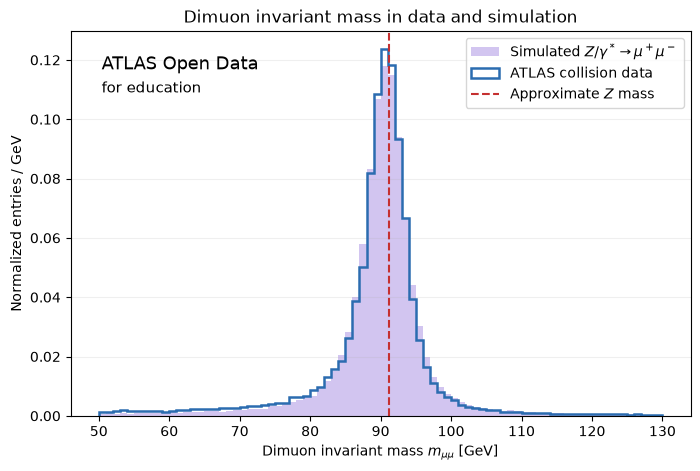

In [7]:
# Add the two muon four-vectors in the collision data.
data_z_candidates = (
    data_pairs[:, 0]
    + data_pairs[:, 1]
)

# Add the two muon four-vectors in the MC simulation.
mc_z_candidates = (
    mc_pairs[:, 0]
    + mc_pairs[:, 1]
)

# Calculate the invariant masses.
data_masses = ak.to_numpy(
    data_z_candidates.mass
)

mc_masses = ak.to_numpy(
    mc_z_candidates.mass
)

print(f"Collision-data dimuon systems: {len(data_masses):,}")
print(f"Simulated dimuon systems:      {len(mc_masses):,}")

# Use the same mass bins for both samples.
mass_bins = np.linspace(
    50,
    130,
    81,
)

fig, ax = plt.subplots(figsize=(8, 5))

# Draw the simulated Z → μμ expectation.
ax.hist(
    mc_masses,
    bins=mass_bins,
    density=True,
    histtype="stepfilled",
    alpha=0.35,
    color="#805ad5",
    label=r"Simulated $Z/\gamma^*\rightarrow\mu^+\mu^-$",
)

# Draw the collision data using the same binning.
ax.hist(
    data_masses,
    bins=mass_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#2b6cb0",
    label="ATLAS collision data",
)

ax.text(
    0.05,
    0.90,
    "ATLAS Open Data",
    transform=ax.transAxes,
    fontsize=13,
)

ax.text(
    0.05,
    0.84,
    "for education",
    transform=ax.transAxes,
    fontsize=11,
)
ax.axvline(
    91.2,
    color="#c53030",
    linestyle="--",
    label=r"Approximate $Z$ mass",
)

ax.set_xlabel(
    r"Dimuon invariant mass $m_{\mu\mu}$ [GeV]"
)
ax.set_ylabel(r"Normalized entries / GeV")
ax.set_title("Dimuon invariant mass in data and simulation")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.show()

Each collision event, when computed using the prior code, gives us a different Z-candidate value of $m_{\mu\mu}$. The purple region represents the ideal behavior of the standard model Z boson found via theoretical calculations. The solid blue outline represents our selected collision data\ processed using the same conditions as the simulated data. If these two data frames show similarities in behavior, it indicates a strong likelihood of the Z boson existing in the ATLAS detector. With this, we have used simple kinematic ideas and structure to detect the likely presence of Z bosons without detecting them directly!

This same principle can be used for many other particle decays, with the general idea centering around the equation:

$$
p_{\text{parent}}^\mu
=
\sum_i p_{\text{daughter},i}^\mu.
$$

## Reference Frames and Two-Body Decays

While invariant mass is the same regardless of relative effects, the energy and momentum of a particle depend greatly on the reference frame from which they are measured. Using the stationary reference frame of the detector is not always the clearest way of understanding how a particle decay occurs.

ATLAS measures particles in the **detector frame** of reference. However, the Z boson is usually in motion as a result of the hard scattering process, and the motion of the parent can hide the simple structure of the decay. For example, the two muons are expected to travel in opposite directions in the Z rest frame, but they may not appear back-to-back in the detector frame.

The event can also be described in the **dimuon rest frame**. This is the reference frame that moves with the combined two-muon system, and moving to this reference frame in analysis is known as a **Lorentz Boost**. A Lorentz boost allows us to remove the overall motion of the parent system. To do this, we change to the reference frame in which the combined dimuon momentum is zero:

$$
\vec p_{\mu\mu}^{\,*}=0.
$$

The asterisk indicates that a quantity is measured in the dimuon rest frame. The most relevant differences and similarities between these reference frames are given below.

| Detector frame | Dimuon rest frame |
|---|---|
| The parent $Z$ boson may be moving | The parent is at rest |
| Parent motion and decay motion are mixed together | The decay motion is isolated |
| The muons may not look back-to-back | The muons are back-to-back |
| Total dimuon momentum may be nonzero | Total dimuon momentum is zero |
| Invariant mass is $m_{\mu\mu}$ | Invariant mass is still $m_{\mu\mu}$ |

Lorentz-boosted values are useful in ATLAS analyses because they can reveal features of a decay that are difficult to accurately represent via the detector frame. For example, the directions of particles in a rest-frame distribution can help physicists study:

- Whether the event is consistent with a particular decay with higher accuracy
- The spin of the parent particle
- How the parent particle interacts with other particles
- Whether or not collision data agrees with a simulated decay model

For this notebook, we will use the rest frame for a simpler purpose: to expose energy and momentum conservation in the $Z\rightarrow\mu^+\mu^-$ decay. For a two-body decay, energy is conserved for two resultant particles with equal masses.

We will take reconstructed dimuon candidates from the prior Monte Carlo sample, boost both muons into their combined rest frame, and test four predictions:

1. The combined momentum of the two muons will be approximately zero
2. The two muons will point in opposite directions
3. The two muons will have equal momentum magnitudes
4. The dimuon invariant mass remains unchanged

In [ ]:
# Reuse the MC dimuon candidates constructed in the invariant-mass section.
# Adding the two reconstructed muon four-vectors gives the energy and momentum of their complete dimuon system.
mc_z_candidates = (
    mc_pairs[:, 0]
    + mc_pairs[:, 1]
)

# Give the individual muon collections descriptive names. These four-vectors are currently expressed in the detector frame.
muon_1_detector = mc_pairs[:, 0]
muon_2_detector = mc_pairs[:, 1]

print(f"MC dimuon systems constructed: {len(mc_z_candidates):,}")

### Applying the Boost

For each simulated event, we first added the two reconstructed muon four-vectors:

$$
p_{\mu\mu}^{\mu}
=
p_{\mu_1}^{\mu}
+
p_{\mu_2}^{\mu}.
$$

In the detector frame, this combined system will usually have nonzero momentum. The four-vectors in `mc_z_candidates` tell us both the direction and speed of that motion.

We now want to describe each pair of muons from the reference frame in which their combined system is at rest. To do this, we apply a Lorentz boost that exactly cancels the momentum of the vectors in `mc_z_candidates`. `boostCM_of_p4(mc_z_candidates)` applies the event-by-event boost into the center-of-momentum frame of each dimuon candidate.  After the boost, we have not changed the physical event; we have only described it from the parent candidate's rest frame. 

In [ ]:
# Boost the first muon into the rest frame of its dimuon system.
muon_1_rest = muon_1_detector.boostCM_of_p4(
    mc_z_candidates
)

# Apply the same event-by-event boost to the second muon.
muon_2_rest = muon_2_detector.boostCM_of_p4(
    mc_z_candidates
)

# This gives the complete dimuon four-vector as measured in the dimuon rest frame.
rest_frame_candidates = (
    muon_1_rest
    + muon_2_rest
)

print("Lorentz boost completed!")

### What Will We Compare?

We now have two descriptions of the same reconstructed events: the original detector-frame four-vectors, and the Lorentz-boosted rest-frame four-vectors. To understand the effect of the boost, we will analyze the four quantities proposed previously.

#### Combined dimuon momentum

$$
|\vec p_{\mu\mu}|
$$

This tells us whether the complete two-muon system is moving in the chosen frame. The magnitude of $p_{\mu\mu}$ should be nonzero in the detector frame and approximately zero in the dimuon rest frame.

#### Opening angle

The opening angle is the three-dimensional angle between the two muon momentum vectors.

- $0$ radians means the muons travel in the same direction
- $\pi/2$ radians means they are perpendicular
- $\pi$ radians means they travel in opposite directions

A two-body system in its rest frame should have an opening angle of $\pi$, meaning they split with opposite momentum, conserving momentum.

#### Individual muon momentum and Invariant Mass

Momentum conservation in the rest frame requires

$$
\vec p_{\mu_1}^{\,*} + \vec p_{\mu_2}^{\,*} = 0.
$$

The two momentum magnitudes must therefore be equal. Further, the boost should not have any effect on the invariant mass of the sample, as it is by definition invariant.

For completeness, when we say that the opening angle in three dimensions should be $\pi$, that is in traditional cylindrical coordinates (with angles $\theta$ and $\phi$). In pseudo-rapidity, the number will be different, though in $\phi$ the particles should always be back-to-back!).

The following code block will compute the values needed to plot and compare these quantities.

In [10]:
def opening_angle(first, second):
    
    # Calculate the three-dimensional angle between two momentum vectors.

    # The dot-product relation is
    #   a · b = |a||b| cos(theta),
    # theta = arccos((a · b) / (|a||b|)).

    dot_product = (
        first.px * second.px
        + first.py * second.py
        + first.pz * second.pz
    )

    magnitude_product = (
        first.p
        * second.p
    )

    cosine = ak.to_numpy(
        dot_product / magnitude_product
    )

    # Protect against tiny numerical values outside the valid range of arccos.
    cosine = np.clip(
        cosine,
        -1,
        1,
    )

    return np.arccos(cosine)


# Momentum of the complete dimuon system in each frame.
detector_momentum = ak.to_numpy(
    mc_z_candidates.p
)

rest_momentum = ak.to_numpy(
    rest_frame_candidates.p
)

# Opening angle between the two muons in each frame.
detector_angle = opening_angle(
    muon_1_detector,
    muon_2_detector,
)

rest_angle = opening_angle(
    muon_1_rest,
    muon_2_rest,
)

# Individual muon momentum magnitudes in the rest frame.
muon_1_rest_momentum = ak.to_numpy(
    muon_1_rest.p
)

muon_2_rest_momentum = ak.to_numpy(
    muon_2_rest.p
)

# Invariant mass of the dimuon system in each frame.
detector_mass = ak.to_numpy(
    mc_z_candidates.mass
)

rest_mass = ak.to_numpy(
    rest_frame_candidates.mass
)

### Combined Motion and the Opening Angle

The following code block will give us two graphs.

The left graph compares the momentum of the complete dimuon system. Before running the cell, consider:

- Why may the parent system have nonzero momentum in the detector frame?
- Where should the rest-frame distribution appear?

The right graph compares the angle between the two muons. Before running the cell, consider:

- Must the muons appear back-to-back in the detector frame?
- What opening angle do we expect in the rest frame?

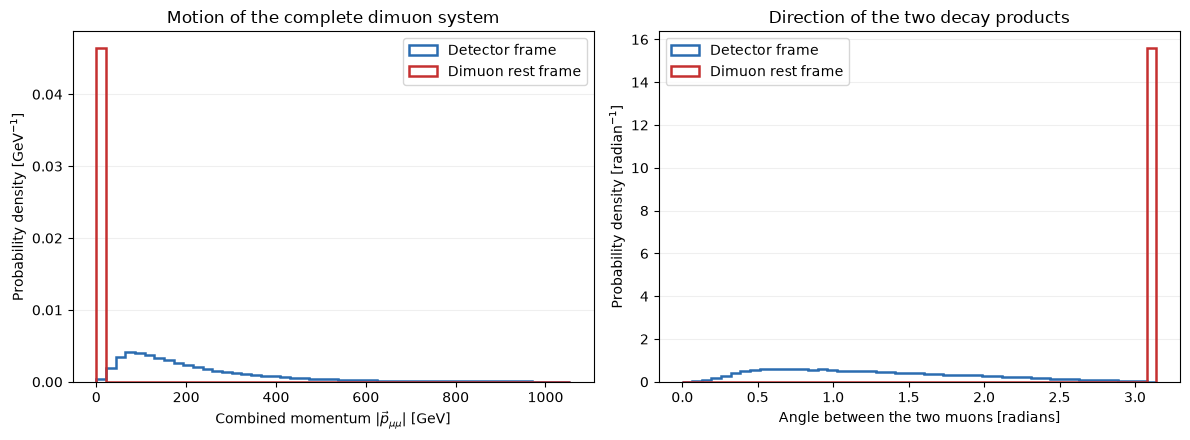

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

# A few unusually energetic events can make the momentum axis unnecessarily large. The 99th percentile keeps the main distribution readable.
momentum_limit = np.percentile(
    detector_momentum,
    99,
)

momentum_bins = np.linspace(
    0,
    momentum_limit,
    50,
)

# Plot the momentum of the complete dimuon system.
axes[0].hist(
    detector_momentum,
    bins=momentum_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#2b6cb0",
    label="Detector frame",
)

axes[0].hist(
    rest_momentum,
    bins=momentum_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#c53030",
    label="Dimuon rest frame",
)

axes[0].set_xlabel(
    r"Combined momentum $|\vec p_{\mu\mu}|$ [GeV]"
)
axes[0].set_title("Motion of the complete dimuon system")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

# Plot the angle between the two muons.
angle_bins = np.linspace(
    0,
    np.pi,
    50,
)

axes[1].hist(
    detector_angle,
    bins=angle_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#2b6cb0",
    label="Detector frame",
)

axes[1].hist(
    rest_angle,
    bins=angle_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#c53030",
    label="Dimuon rest frame",
)

# Add text 'ATLAS Open Data' on plot
ax.text(
    0.05,
    0.90,
    "ATLAS Open Data",
    transform=ax.transAxes,fontsize=13,)


# Add text 'for education' on plot
ax.text(
    0.05,
    0.84,
    "for education",
    transform=ax.transAxes,fontsize=11,)

axes[1].set_xlabel("Angle between the two muons [radians]")
axes[1].set_title("Direction of the two decay products")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)
axes[0].set_ylabel(r"Probability density [GeV$^{-1}$]")
axes[1].set_ylabel(r"Probability density [radian$^{-1}$]")

plt.tight_layout()
plt.show()

### Interpreting the Result

In the detector frame, the dimuon systems have a range of momenta, due to their parent particles appearing with different amounts of motion in the proton collisions. After the Lorentz boost, the combined dimuon momentum is approximately zero, the defining quality of the rest frame

The two muons are also not always back-to-back in the detector frame. Their measured directions include both:

- Their relative motion from the decay
- The motion of the parent system through the detector

After the parent's overall motion is removed, the opening angle becomes approximately

$$
\theta_{\mu\mu}^{*}=\pi.
$$

This exposes the underlying two-body structure of the decay.

#### Check your understanding

1. Did the boost make the parent stop physically inside the detector?
2. Why does the combined momentum become zero after the boost?
3. Why are the muons back-to-back only in the rest frame?

### Testing Momentum Conservation

As we said before, for a two-body system in its rest frame,

$$
\vec p_{\mu_1}^{\,*}
+
\vec p_{\mu_2}^{\,*}
=
0.
$$

These vectors will point in opposite directions, so their magnitudes must be equal:

$$
|\vec p_{\mu_1}^{\,*}|
=
|\vec p_{\mu_2}^{\,*}|.
$$

The next graph places the momentum magnitude of the first muon on the horizontal axis and that of the second muon on the vertical axis. If momentum is conserved, where should the points appear relative to each other?

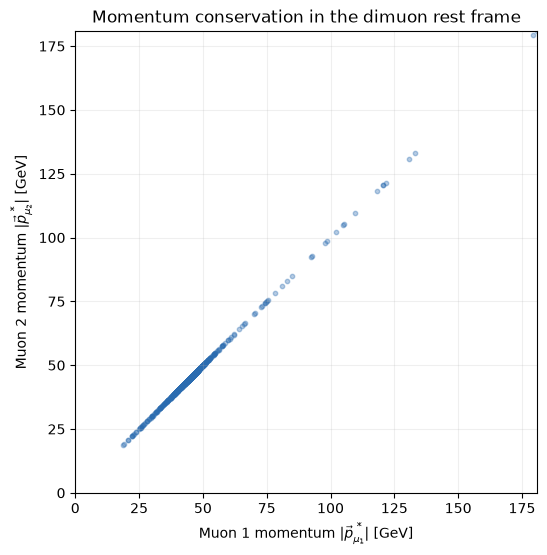

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot a subset so that individual points remain visible.
number_to_plot = min(
    2_000,
    len(muon_1_rest_momentum),
)

ax.scatter(
    muon_1_rest_momentum[:number_to_plot],
    muon_2_rest_momentum[:number_to_plot],
    s=10,
    alpha=0.35,
    color="#2b6cb0",
)

largest_muon_momentum = max(
    np.max(
        muon_1_rest_momentum[:number_to_plot]
    ),
    np.max(
        muon_2_rest_momentum[:number_to_plot]
    ),
)


ax.set_xlim(0, largest_muon_momentum)
ax.set_ylim(0, largest_muon_momentum)
ax.set_aspect("equal")
ax.set_xlabel(
    r"Muon 1 momentum $|\vec p_{\mu_1}^{\,*}|$ [GeV]"
)
ax.set_ylabel(
    r"Muon 2 momentum $|\vec p_{\mu_2}^{\,*}|$ [GeV]"
)
ax.set_title("Momentum conservation in the dimuon rest frame")
ax.grid(alpha=0.2)

plt.show()

The points create a linear distribution, showing that the two reconstructed muons have equal momentum magnitudes in their combined rest frame. This does not mean that every event has the same muon momentum. Different dimuon systems can have different invariant masses. It means that, within each individual event,

$$
|\vec p_{\mu_1}^{\,*}|
=
|\vec p_{\mu_2}^{\,*}|.
$$

Together with the opening angle of $\pi$, this means that the momentum vectors are equal in magnitude and opposite in sign.

### Checking the Invariant Mass

The Lorentz boost changed the muon energies and momentum components. It should not change the dimuon invariant mass. For every event, we calculate:

$$
\Delta m
=
m_{\mu\mu}^{*}
-
m_{\mu\mu},
$$

where:

- $m_{\mu\mu}$ is calculated in the detector frame
- $m_{\mu\mu}^{*}$ is calculated in the dimuon rest frame

If mass is Lorentz invariant, where should the distribution of $\Delta m$ appear?

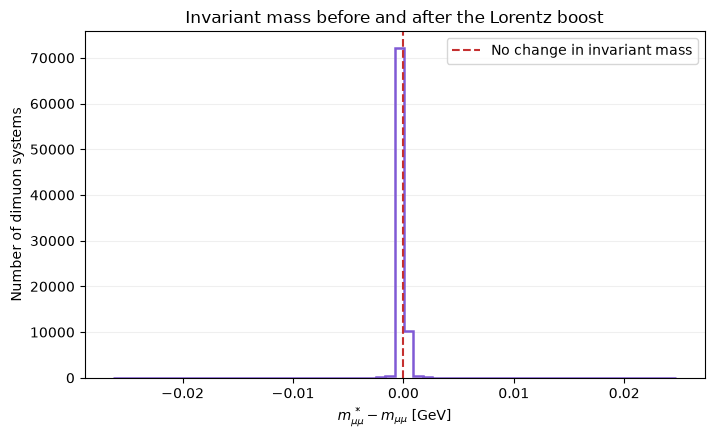

Largest absolute numerical change in invariant mass: 2.632e-02 GeV


In [13]:
mass_difference = (
    rest_mass
    - detector_mass
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    mass_difference,
    bins=60,
    histtype="step",
    linewidth=1.8,
    color="#805ad5",
)

ax.axvline(
    0,
    color="#c53030",
    linestyle="--",
    label="No change in invariant mass",
)

ax.set_xlabel(
    r"$m_{\mu\mu}^{\,*}-m_{\mu\mu}$ [GeV]"
)
ax.set_ylabel("Number of dimuon systems")
ax.set_title("Invariant mass before and after the Lorentz boost")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.show()

print(
    "Largest absolute numerical change in invariant mass: "
    f"{np.max(abs(mass_difference)):.3e} GeV"
)

The distribution appears at zero, as:

$$
m_{\mu\mu}^{*}=m_{\mu\mu}.
$$

As you may see, there will be a very very slight variance in mass. This is due to the error introduced by floating point calculations, and can be disregarded for this simple analysis. The Lorentz boost changed the energies, momenta, and directions used to describe the muons, but it did not change the reconstructed mass of their combined system. Using reconstructed ATLAS Monte Carlo events, we have now connected:

$$
\text{four-vector addition}
\longrightarrow
\text{Lorentz boost}
\longrightarrow
\text{parent rest frame}
\longrightarrow
\text{two-body momentum conservation}.
$$

## Summary

You've now made it to the end of the kinematics notebook! If you've made it this far, you now know:

- How to load Monte Carlo and collision data using `atlasopenmagic`
- How and why to calculate four-vectors for events
- How we can use basic conservation laws to select events that match our simulation
- The role of invariant mass in particle kinematics, and how to use it to discover short-lived particles
- How relativity and reference frames affect particle kinematics
- The intrinsic properties of two-body decays
- What a Lorentz boost is, how it affects data values, and how it can be used in an analysis

If you're interested in learning more, here are some continued learning questions and topics:

1. Would adding only the transverse momenta be enough to reconstruct the full invariant mass?
2. Why can muons appear not opposite one another (back-to-back) in the detector's reference frame?
3. Try a similar analysis centered around the $Z\rightarrow e^+e^-$ decay channel, as electrons behave differently in the ATLAS detector.
4. Try using these principles in events with a neutrino; like $W\rightarrow\ell\nu$. What extra complications do neutrinos introduce? (Hint: does the detector measure neutrinos? Could it indirectly measure neutrinos?)5. Try using a multi-body decay, like top quark decays. Top quarks come in pairs, so there will be additional complications to separating the decay products from each top quark.6. Try checking the masses of the individual muons in the event. What values do you find? Why?7. In the distribution of muon momenta in the dimuon rest frame that you plotted earlier, why does the distribution look the way it does?8. The distribution of Z-boson masses that you drew has a width - not all Z boson candidates have exactly the same mass. Why might that be? What contributes to the width? Is it the same for electron masses and muon masses?

<div class="alert alert-block alert-info">
We welcome your feedback on this notebook or any of our other materials! Please <a href="https://forms.gle/zKBqS1opAHHemv9U7">fill out this survey</a> to let us know how we're doing, and you can enter a raffle to win some <a href="https://atlas-secretariat.web.cern.ch/merchandise">ATLAS merchandise</a>!
</div>